# **Import libaries and dataset**

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
wine = pd.read_csv("winedata.csv")
wine

,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak,Adams,Allen,Anderson,...,Turner,Walker,Ward,Watson,White,Williams,Wilson,Wood,Wright,Young
0,1,January,Malbec,72,56,France,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
1,2,January,Pinot Noir,72,17,France,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,February,Espumante,144,32,Oregon,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,February,Champagne,72,48,France,True,NaN,NaN,NaN,...,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,5,February,Cabernet Sauvignon,144,44,New Zealand,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,March,Prosecco,144,86,Chile,False,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
6,7,March,Prosecco,6,40,Australia,True,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
7,8,March,Espumante,6,45,South Africa,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
8,9,April,Chardonnay,144,57,Chile,False,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
9,10,April,Prosecco,72,52,California,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN


In [3]:
# Replace missing values (NaN) with 0
wine.fillna(0, inplace=True)
wine

,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak,Adams,Allen,Anderson,...,Turner,Walker,Ward,Watson,White,Williams,Wilson,Wood,Wright,Young
0,1,January,Malbec,72,56,France,False,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,January,Pinot Noir,72,17,France,False,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,February,Espumante,144,32,Oregon,True,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,February,Champagne,72,48,France,True,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,February,Cabernet Sauvignon,144,44,New Zealand,True,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,6,March,Prosecco,144,86,Chile,False,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
6,7,March,Prosecco,6,40,Australia,True,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,8,March,Espumante,6,45,South Africa,False,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8,9,April,Chardonnay,144,57,Chile,False,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,10,April,Prosecco,72,52,California,False,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# **Clustering anlaysis**

In [4]:
# Select only columns starting from index 8 (customer purchase data)
clustering_data = wine.iloc[:, 7:].T

clustering_data

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
Adams,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
Allen,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Anderson,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Bailey,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Baker,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Williams,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Wilson,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Wood,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Wright,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Rename columns using "Offer #"
clustering_data.columns = wine["Offer #"].values
clustering_data

,1,2,3,4,5,6,7,8,9,10,...,23,24,25,26,27,28,29,30,31,32
Adams,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
Allen,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Anderson,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Bailey,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Baker,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Williams,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Wilson,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Wood,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Wright,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


note that each column is an offer, each row is a customer

# **K-means analaysis**

## clustering with 4 clusters

In [6]:
# Set random seed for reproducibility
np.random.seed(12345)

In [7]:
# K-means clustering with 4 clusters
kmeans_4 = KMeans(n_clusters=4, n_init=100, random_state=12345)
kmeans_4.fit(clustering_data)

KMeans(n_clusters=4, n_init=100, random_state=12345)

In [8]:
print("Cluster sizes:", np.bincount(kmeans_4.labels_))

Cluster sizes: [21 27 36 16]



`kmeans_4.labels_`
- An array where each element represents the **cluster label** assigned to the corresponding observation by the k-means clustering algorithm.

`np.bincount`
- Counts the occurrences of each unique label in the array.
- This gives the **number of data points in each cluster**, allowing you to observe the size of each cluster.


In [9]:
# Cluster centers
kmeans_4.cluster_centers_

array([[ 2.38095238e-01,  9.52380952e-02,  1.90476190e-01,
         1.90476190e-01,  4.76190476e-02,  2.85714286e-01,
         1.42857143e-01,  1.42857143e-01,  9.52380952e-02,
         9.52380952e-02,  2.38095238e-01,  9.52380952e-02,
        -2.77555756e-17,  1.90476190e-01,  1.90476190e-01,
        -6.93889390e-18, -2.77555756e-17,  4.76190476e-02,
         1.42857143e-01,  4.76190476e-02,  9.52380952e-02,
         1.00000000e+00,  9.52380952e-02, -5.55111512e-17,
         9.52380952e-02,  4.76190476e-02,  1.42857143e-01,
         9.52380952e-02,  8.32667268e-17,  1.90476190e-01,
         3.33333333e-01,  4.76190476e-02],
       [-2.77555756e-17, -2.77555756e-17, -3.46944695e-17,
        -6.93889390e-17, -6.93889390e-18,  3.70370370e-02,
         4.44444444e-01,  4.44444444e-01, -2.77555756e-17,
         3.70370370e-02,  8.32667268e-17, -1.38777878e-17,
         2.22222222e-01,  0.00000000e+00, -3.46944695e-17,
        -1.38777878e-17, -4.16333634e-17,  4.81481481e-01,
        -1.38

In [10]:
kmeans_4.cluster_centers_.shape

(4, 32)

In [11]:
# Create a DataFrame for cluster centers with row and column names, this is just for us to see in a easier way
pd.set_option('display.float_format', '{:.4f}'.format)  # Set global display format
cluster_centers_df = pd.DataFrame(
    kmeans_4.cluster_centers_,
    columns=[str(i) for i in range(1, 33)],  # Column names: 1, 2, ..., 32
    index=[f"Cluster {i}" for i in range(1, 5)]  # Row names: Cluster 1, Cluster 2, ..., Cluster 4
)
cluster_centers_df

,1,2,3,4,5,6,7,8,9,10,...,23,24,25,26,27,28,29,30,31,32
Cluster 1,0.2381,0.0952,0.1905,0.1905,0.0476,0.2857,0.1429,0.1429,0.0952,0.0952,...,0.0952,-0.0000,0.0952,0.0476,0.1429,0.0952,0.0000,0.1905,0.3333,0.0476
Cluster 2,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0370,0.4444,0.4444,-0.0000,0.0370,...,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0370,0.5926,0.5926,0.0000,-0.0000
Cluster 3,0.1111,0.0556,0.0556,0.2222,0.0833,0.1389,0.1111,0.1389,0.2222,0.0833,...,0.0556,-0.0000,0.1111,0.0556,0.1389,0.0833,0.0278,0.0556,0.2778,0.0833
Cluster 4,0.0625,0.3750,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0625,...,0.0625,0.7500,-0.0000,0.7500,0.0625,-0.0000,0.0000,-0.0000,0.0000,0.0000


Now we want to combine the original data with clust result


In [12]:
wine.iloc[:, :7]

,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak
0,1,January,Malbec,72,56,France,False
1,2,January,Pinot Noir,72,17,France,False
2,3,February,Espumante,144,32,Oregon,True
3,4,February,Champagne,72,48,France,True
4,5,February,Cabernet Sauvignon,144,44,New Zealand,True
5,6,March,Prosecco,144,86,Chile,False
6,7,March,Prosecco,6,40,Australia,True
7,8,March,Espumante,6,45,South Africa,False
8,9,April,Chardonnay,144,57,Chile,False
9,10,April,Prosecco,72,52,California,False


In [13]:
kmeans_4.cluster_centers_.shape


(4, 32)

In [14]:
# Assign cluster means to the dataset
cluster_means_4 = pd.DataFrame(
    np.hstack([wine.iloc[:, :7].values, kmeans_4.cluster_centers_.T]),
    columns=list(wine.columns[:7]) + [f"Cluster {i + 1}" for i in range(4)]
)
cluster_means_4


,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak,Cluster 1,Cluster 2,Cluster 3,Cluster 4
0,1,January,Malbec,72,56,France,False,0.2381,-0.0000,0.1111,0.0625
1,2,January,Pinot Noir,72,17,France,False,0.0952,-0.0000,0.0556,0.3750
2,3,February,Espumante,144,32,Oregon,True,0.1905,-0.0000,0.0556,-0.0000
3,4,February,Champagne,72,48,France,True,0.1905,-0.0000,0.2222,-0.0000
4,5,February,Cabernet Sauvignon,144,44,New Zealand,True,0.0476,-0.0000,0.0833,0.0000
5,6,March,Prosecco,144,86,Chile,False,0.2857,0.0370,0.1389,-0.0000
6,7,March,Prosecco,6,40,Australia,True,0.1429,0.4444,0.1111,0.0000
7,8,March,Espumante,6,45,South Africa,False,0.1429,0.4444,0.1389,-0.0000
8,9,April,Chardonnay,144,57,Chile,False,0.0952,-0.0000,0.2222,-0.0000
9,10,April,Prosecco,72,52,California,False,0.0952,0.0370,0.0833,0.0625


In [15]:
cluster_means_4.sort_values(by="Cluster 1", ascending=False)


,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak,Cluster 1,Cluster 2,Cluster 3,Cluster 4
21,22,August,Champagne,72,63,France,False,1.0000,0.0000,0.0000,0.0000
30,31,December,Champagne,72,89,France,False,0.3333,0.0000,0.2778,0.0000
5,6,March,Prosecco,144,86,Chile,False,0.2857,0.0370,0.1389,-0.0000
10,11,May,Champagne,72,85,France,False,0.2381,0.0000,0.2222,0.0000
0,1,January,Malbec,72,56,France,False,0.2381,-0.0000,0.1111,0.0625
13,14,June,Merlot,72,64,Chile,False,0.1905,0.0000,0.1389,-0.0000
29,30,December,Malbec,6,54,France,False,0.1905,0.5926,0.0556,-0.0000
3,4,February,Champagne,72,48,France,True,0.1905,-0.0000,0.2222,-0.0000
14,15,June,Cabernet Sauvignon,144,19,Italy,False,0.1905,-0.0000,0.0556,-0.0000
2,3,February,Espumante,144,32,Oregon,True,0.1905,-0.0000,0.0556,-0.0000


In [16]:
cluster_means_4.sort_values(by="Cluster 2", ascending=False)

,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak,Cluster 1,Cluster 2,Cluster 3,Cluster 4
28,29,November,Pinot Grigio,6,87,France,False,0.0000,0.5926,0.0278,0.0000
29,30,December,Malbec,6,54,France,False,0.1905,0.5926,0.0556,-0.0000
17,18,July,Espumante,6,50,Oregon,False,0.0476,0.4815,0.0000,-0.0000
6,7,March,Prosecco,6,40,Australia,True,0.1429,0.4444,0.1111,0.0000
7,8,March,Espumante,6,45,South Africa,False,0.1429,0.4444,0.1389,-0.0000
12,13,May,Merlot,6,43,Chile,False,-0.0000,0.2222,-0.0000,-0.0000
27,28,November,Cabernet Sauvignon,12,56,France,True,0.0952,0.0370,0.0833,-0.0000
20,21,August,Champagne,12,50,California,False,0.0952,0.0370,0.0278,0.0000
9,10,April,Prosecco,72,52,California,False,0.0952,0.0370,0.0833,0.0625
5,6,March,Prosecco,144,86,Chile,False,0.2857,0.0370,0.1389,-0.0000


In [17]:
cluster_means_4.sort_values(by="Cluster 3", ascending=False)

,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak,Cluster 1,Cluster 2,Cluster 3,Cluster 4
30,31,December,Champagne,72,89,France,False,0.3333,0.0000,0.2778,0.0000
10,11,May,Champagne,72,85,France,False,0.2381,0.0000,0.2222,0.0000
8,9,April,Chardonnay,144,57,Chile,False,0.0952,-0.0000,0.2222,-0.0000
3,4,February,Champagne,72,48,France,True,0.1905,-0.0000,0.2222,-0.0000
7,8,March,Espumante,6,45,South Africa,False,0.1429,0.4444,0.1389,-0.0000
13,14,June,Merlot,72,64,Chile,False,0.1905,0.0000,0.1389,-0.0000
26,27,October,Champagne,72,88,New Zealand,False,0.1429,0.0000,0.1389,0.0625
19,20,August,Cabernet Sauvignon,72,82,Italy,False,0.0476,-0.0000,0.1389,-0.0000
5,6,March,Prosecco,144,86,Chile,False,0.2857,0.0370,0.1389,-0.0000
6,7,March,Prosecco,6,40,Australia,True,0.1429,0.4444,0.1111,0.0000


In [18]:
cluster_means_4.sort_values(by="Cluster 4", ascending=False)

,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak,Cluster 1,Cluster 2,Cluster 3,Cluster 4
23,24,September,Pinot Noir,6,34,Italy,False,-0.0000,-0.0000,-0.0000,0.7500
25,26,October,Pinot Noir,144,83,Australia,False,0.0476,0.0000,0.0556,0.7500
16,17,July,Pinot Noir,12,47,Germany,False,-0.0000,-0.0000,0.0000,0.4375
1,2,January,Pinot Noir,72,17,France,False,0.0952,-0.0000,0.0556,0.3750
0,1,January,Malbec,72,56,France,False,0.2381,-0.0000,0.1111,0.0625
26,27,October,Champagne,72,88,New Zealand,False,0.1429,0.0000,0.1389,0.0625
11,12,May,Prosecco,72,83,Australia,False,0.0952,-0.0000,0.0556,0.0625
22,23,September,Chardonnay,144,39,South Africa,False,0.0952,-0.0000,0.0556,0.0625
15,16,June,Merlot,72,88,California,False,-0.0000,-0.0000,0.1111,0.0625
9,10,April,Prosecco,72,52,California,False,0.0952,0.0370,0.0833,0.0625


## clustering with 3 clusters

In [19]:
# K-means clustering with 3 clusters
kmeans_3 = KMeans(n_clusters=3, n_init=100, random_state=12345)
kmeans_3.fit(clustering_data)

KMeans(n_clusters=3, n_init=100, random_state=12345)

In [20]:
print("Cluster sizes:", np.bincount(kmeans_3.labels_))

Cluster sizes: [16 49 35]


In [21]:
# Cluster centers
kmeans_3.cluster_centers_

array([[ 6.25000000e-02,  3.75000000e-01, -2.77555756e-17,
        -5.55111512e-17,  0.00000000e+00, -5.55111512e-17,
         2.77555756e-17, -2.77555756e-17, -1.38777878e-17,
         6.25000000e-02,  5.55111512e-17,  6.25000000e-02,
        -2.77555756e-17, -1.38777878e-17, -2.77555756e-17,
         6.25000000e-02,  4.37500000e-01, -5.55111512e-17,
        -6.93889390e-18, -2.77555756e-17,  0.00000000e+00,
         0.00000000e+00,  6.25000000e-02,  7.50000000e-01,
        -2.77555756e-17,  7.50000000e-01,  6.25000000e-02,
        -2.77555756e-17,  5.55111512e-17, -8.32667268e-17,
         5.55111512e-17,  0.00000000e+00],
       [ 1.83673469e-01,  8.16326531e-02,  8.16326531e-02,
         2.44897959e-01,  8.16326531e-02,  2.24489796e-01,
         6.12244898e-02,  6.12244898e-02,  2.04081633e-01,
         8.16326531e-02,  2.65306122e-01,  6.12244898e-02,
        -4.16333634e-17,  1.83673469e-01,  1.22448980e-01,
         8.16326531e-02,  5.55111512e-17,  2.04081633e-02,
         8.16

In [22]:
kmeans_3.cluster_centers_.shape

(3, 32)

In [23]:
# Assign cluster means to the dataset
cluster_means_3 = pd.DataFrame(
    np.hstack([wine.iloc[:, :7].values, kmeans_3.cluster_centers_.T]),
    columns=list(wine.columns[:7]) + [f"Cluster {i + 1}" for i in range(3)]
)
cluster_means_3

,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak,Cluster 1,Cluster 2,Cluster 3
0,1,January,Malbec,72,56,France,False,0.0625,0.1837,-0.0000
1,2,January,Pinot Noir,72,17,France,False,0.3750,0.0816,-0.0000
2,3,February,Espumante,144,32,Oregon,True,-0.0000,0.0816,0.0571
3,4,February,Champagne,72,48,France,True,-0.0000,0.2449,-0.0000
4,5,February,Cabernet Sauvignon,144,44,New Zealand,True,0.0000,0.0816,-0.0000
5,6,March,Prosecco,144,86,Chile,False,-0.0000,0.2245,0.0286
6,7,March,Prosecco,6,40,Australia,True,0.0000,0.0612,0.4571
7,8,March,Espumante,6,45,South Africa,False,-0.0000,0.0612,0.4857
8,9,April,Chardonnay,144,57,Chile,False,-0.0000,0.2041,-0.0000
9,10,April,Prosecco,72,52,California,False,0.0625,0.0816,0.0571


In [24]:
cluster_means_3.sort_values(by="Cluster 1", ascending=False)

,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak,Cluster 1,Cluster 2,Cluster 3
23,24,September,Pinot Noir,6,34,Italy,False,0.7500,-0.0000,-0.0000
25,26,October,Pinot Noir,144,83,Australia,False,0.7500,0.0612,-0.0000
16,17,July,Pinot Noir,12,47,Germany,False,0.4375,0.0000,0.0000
1,2,January,Pinot Noir,72,17,France,False,0.3750,0.0816,-0.0000
0,1,January,Malbec,72,56,France,False,0.0625,0.1837,-0.0000
26,27,October,Champagne,72,88,New Zealand,False,0.0625,0.1429,0.0286
11,12,May,Prosecco,72,83,Australia,False,0.0625,0.0612,0.0286
22,23,September,Chardonnay,144,39,South Africa,False,0.0625,0.0816,-0.0000
15,16,June,Merlot,72,88,California,False,0.0625,0.0816,-0.0000
9,10,April,Prosecco,72,52,California,False,0.0625,0.0816,0.0571


In [25]:
cluster_means_3.sort_values(by="Cluster 2", ascending=False)

,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak,Cluster 1,Cluster 2,Cluster 3
21,22,August,Champagne,72,63,France,False,0.0000,0.4082,0.0286
30,31,December,Champagne,72,89,France,False,0.0000,0.3469,0.0000
10,11,May,Champagne,72,85,France,False,0.0000,0.2653,0.0000
3,4,February,Champagne,72,48,France,True,-0.0000,0.2449,-0.0000
5,6,March,Prosecco,144,86,Chile,False,-0.0000,0.2245,0.0286
8,9,April,Chardonnay,144,57,Chile,False,-0.0000,0.2041,-0.0000
13,14,June,Merlot,72,64,Chile,False,-0.0000,0.1837,0.0000
0,1,January,Malbec,72,56,France,False,0.0625,0.1837,-0.0000
26,27,October,Champagne,72,88,New Zealand,False,0.0625,0.1429,0.0286
29,30,December,Malbec,6,54,France,False,-0.0000,0.1224,0.4571


In [26]:
cluster_means_3.sort_values(by="Cluster 3", ascending=False)

,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak,Cluster 1,Cluster 2,Cluster 3
7,8,March,Espumante,6,45,South Africa,False,-0.0000,0.0612,0.4857
29,30,December,Malbec,6,54,France,False,-0.0000,0.1224,0.4571
6,7,March,Prosecco,6,40,Australia,True,0.0000,0.0612,0.4571
28,29,November,Pinot Grigio,6,87,France,False,0.0000,0.0204,0.4571
17,18,July,Espumante,6,50,Oregon,False,-0.0000,0.0204,0.3714
12,13,May,Merlot,6,43,Chile,False,-0.0000,-0.0000,0.1714
9,10,April,Prosecco,72,52,California,False,0.0625,0.0816,0.0571
2,3,February,Espumante,144,32,Oregon,True,-0.0000,0.0816,0.0571
20,21,August,Champagne,12,50,California,False,0.0000,0.0408,0.0571
21,22,August,Champagne,72,63,France,False,0.0000,0.4082,0.0286


## Experiment with different numbers of clusters (not required)

In [27]:
# Calculate global mean and total variance
global_mean = np.mean(clustering_data, axis=0)
total_variance = np.sum(np.sum((clustering_data - global_mean) ** 2, axis=1))

# Initialize metrics
wss, bss, pseudoF, wssbss = [], [], [], []

for i in range(2, 16):
    kmeans_i = KMeans(n_clusters=i, n_init=50, random_state=12345)
    kmeans_i.fit(clustering_data)

    current_wss = kmeans_i.inertia_
    wss.append(current_wss)

    # Calculate BSS
    current_bss = total_variance - current_wss
    bss.append(current_bss)

    # Pseudo-F and WSS/BSS
    pseudoF.append((current_bss / (i - 1)) / (current_wss / (clustering_data.shape[0] - i)))
    wssbss.append(current_wss / current_bss)



### Explanation of code
This block evaluates different clustering metrics for a range of cluster numbers to help determine the optimal number of clusters for a k-means clustering model.

#### Variables:

- wss: Within-cluster Sum of Squares, a measure of compactness (lower is better).
- bss: Between-cluster Sum of Squares, a measure of separation (higher is better).
- pseudoF: A statistic combining WSS and BSS to assess clustering quality.
- wssbss: Ratio of WSS to BSS, used for analysis of clustering efficiency.-

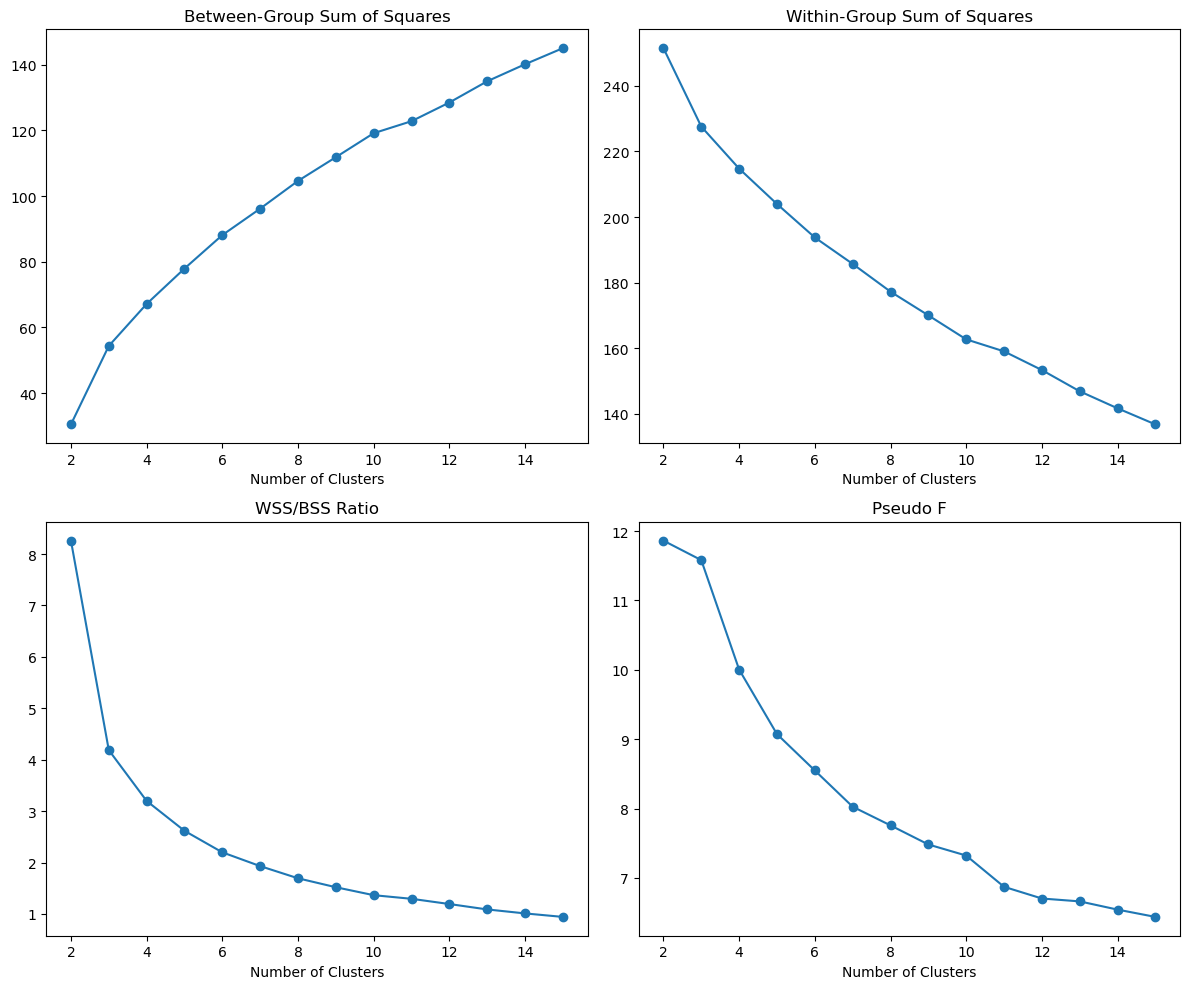

In [28]:
# Plot metrics for cluster evaluation
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.plot(range(2, 16), bss, marker='o')
plt.title("Between-Group Sum of Squares")
plt.xlabel("Number of Clusters")

plt.subplot(2, 2, 2)
plt.plot(range(2, 16), wss, marker='o')
plt.title("Within-Group Sum of Squares")
plt.xlabel("Number of Clusters")

plt.subplot(2, 2, 3)
plt.plot(range(2, 16), wssbss, marker='o')
plt.title("WSS/BSS Ratio")
plt.xlabel("Number of Clusters")

plt.subplot(2, 2, 4)
plt.plot(range(2, 16), pseudoF, marker='o')
plt.title("Pseudo F")
plt.xlabel("Number of Clusters")

plt.tight_layout()
plt.show()

### Comments on the Plots

#### Top-Left: Between-Group Sum of Squares (BSS)
This plot shows a steady **increase** as the number of clusters increases. This behavior is expected because adding more clusters improves the separation of the data into distinct groups, thereby increasing the BSS.

#### Top-Right: Within-Group Sum of Squares (WSS)
This plot shows a steady **decrease** as the number of clusters increases. This is expected because adding more clusters reduces the variance within each cluster, making them more compact.

#### Bottom-Left: WSS/BSS Ratio
The WSS/BSS ratio decreases as the number of clusters increases. This is expected because WSS diminishes faster than BSS increases, resulting in a smaller ratio. The "elbow-like" drop around clusters **3–5** suggests an optimal range for the number of clusters.

#### Bottom-Right: Pseudo-F Statistic
The Pseudo-F statistic decreases steadily from 2 clusters onward, without a distinct peak. This indicates that the clusters become less clearly defined as the number of clusters increases.


### Optimal Number of Clusters

Based on the graphs:

#### Elbow Method (WSS/BSS Ratio)
- The WSS/BSS plot shows a sharp decrease around **3–4 clusters**, indicating that adding more clusters after this point provides diminishing returns.

#### Pseudo-F Statistic
- The pseudo-F plot decreases steadily from **2 clusters onward**, without a clear peak. This suggests that while pseudo-F provides insight into the clustering quality, it does not strongly indicate an optimal number of clusters.

#### Between-Group and Within-Group Sum of Squares
- The behavior of these metrics aligns with expectations:
  - **BSS steadily increases**, reflecting better separation with more clusters.
  - **WSS steadily decreases**, reflecting more compact clusters.
- However, neither metric independently suggests an optimal number of clusters. Instead, they indicate diminishing returns as the number of clusters increases.

### Suggested Optimal Cluster Range
The **3–4 clusters** range is likely the best choice based on the WSS/BSS ratio and the diminishing returns shown in the graphs.
